# E1 — EfficientFormerV2-S0 + TSM + FrameMean — Seed 0
## Controlled transfer test of cross-frame feature mixing

Tujuan E1:

> **Apakah cross-frame feature mixing yang memberi keuntungan pada MobileNetV2+TSM juga dapat dipindahkan ke EfficientFormerV2-S0?**

Arsitektur yang diuji:

```text
16 frames
→ EfficientFormerV2-S0 stem
→ Stage 1
→ Stage 2
→ Stage 3
→ TSM (shift_div=8)
→ Stage 4
→ EfficientFormerV2 norm + global pooling
→ FrameMean
→ classifier
```

TSM ditempatkan **setelah Stage 3** (Python index `2`, width 96 pada EfficientFormerV2-S0) dan **sebelum Stage 4**. Ini adalah placement E1 yang ditetapkan a priori.

Semua komponen lain dipertahankan dari baseline FrameMean: split data, cache 16 frame, preprocessing, augmentation, backbone, classifier, optimizer, learning rate, scheduler, early stopping, dan loss. Tidak ada BiLSTM dan tidak ada temporal attention.

Eksperimen awal ini menggunakan **seed 0**. RWF-2000 tetap held-out dan tidak digunakan untuk training, validation, checkpoint selection, atau tuning placement.


In [1]:

# Instalasi dependensi. Jalankan sekali pada awal sesi Colab.
!pip -q install timm ptflops


In [2]:

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:

import os
import json
import math
import time
import random
import shutil
import platform
import warnings
from contextlib import nullcontext
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision.transforms import functional as TF
from torchvision.transforms import RandomResizedCrop, InterpolationMode

import timm
from timm import create_model
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    roc_curve,
)

warnings.filterwarnings("ignore", category=UserWarning)

print("Python :", platform.python_version())
print("PyTorch:", torch.__version__)
print("timm   :", timm.__version__)
print("CUDA   :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU    :", torch.cuda.get_device_name(0))


Python : 3.13.15
PyTorch: 2.11.0+cu128
timm   : 1.0.28
CUDA   : True
GPU    : NVIDIA A100-SXM4-40GB


## 1. Konfigurasi E1

Eksperimen ini hanya menjalankan:

```text
EfficientFormerV2-S0 + TSM(after Stage 3) + FrameMean
seed = 0
```

`FIXED_SPLIT_SEED=42` tetap dipertahankan agar identitas train/validation sama dengan baseline FrameMean.


In [4]:

# =========================
# PATH — EDIT BAGIAN INI
# =========================
DATA_ROOT = Path("/content/drive/MyDrive/IVS/ViolenceDataset/EffTempNet_Data")
CACHE_DIR = Path("/content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/new_saved_dataset")
OUTPUT_DIR = Path("/content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/EffTempNet_EFv2TSM_S3_FrameMean_Seed42_v1")

TRAINVAL_DIR = DATA_ROOT / "TrainVal" / "Gabung"

# Lokasi video mentah RWF (dipakai hanya bila cache belum ada)
RWF_RAW_DIR = Path("/content/drive/MyDrive/IVS/ViolenceDataset/Benchmark/RWF")

TEST_SPECS = {
    "HF":   {"raw_dir": DATA_ROOT / "Testing" / "HockeyFight",  "cache_name": "HockeyFight"},
    "MF":   {"raw_dir": DATA_ROOT / "Testing" / "MovieFight",   "cache_name": "MovieFight"},
    "VCF":  {"raw_dir": DATA_ROOT / "Testing" / "ViolentFlow", "cache_name": "ViolentFlow"},
    "AVDV": {"raw_dir": DATA_ROOT / "Testing" / "Automatic",   "cache_name": "Automatic"},
    "SCFD": {"raw_dir": DATA_ROOT / "Testing" / "SurveilFight","cache_name": "Surveilence"},
    "RLVS": {"raw_dir": DATA_ROOT / "Testing" / "Realife",     "cache_name": "Realife"},
    "RWF":  {"raw_dir": RWF_RAW_DIR,                           "cache_name": "RWF"},
}

# RWF adalah domain HELD-OUT: dievaluasi terpisah, TIDAK masuk ALL_TESTS_POOLED,
# agar pooled tetap 411 klip dan sebanding dengan seluruh eksperimen sebelumnya.
POOLED_DATASETS = ["HF", "MF", "VCF", "AVDV", "SCFD", "RLVS"]

# =========================
# EKSPERIMEN WAJIB
# =========================
RUN_SEED = 42
SEEDS = [RUN_SEED]
REQUIRED_VARIANTS = ["efv2_tsm_s3_frame_mean"]

# Smoke test untuk mengecek pipeline. Ubah False sebelum eksperimen final.
SMOKE_TEST = False

# =========================
# DATA DAN MODEL
# =========================
CLASS_NAMES = ["NonViolence", "Violence"]
NUM_CLASSES = 2
SEQUENCE_LENGTH = 16
RAW_HEIGHT = 64
RAW_WIDTH = 64
BACKBONE_INPUT_SIZE = 224

# =========================
# E1 — TEMPORAL SHIFT
# =========================
USE_TSM = True
TSM_SHIFT_DIV = 8

# EfficientFormerV2-S0: stage indices are 0,1,2,3.
# E1 fixed placement: after Stage 3 (index 2), before Stage 4.
TSM_AFTER_STAGE_INDICES = (2,)
TSM_PLACEMENT_NAME = "after_stage3_before_stage4"

VAL_RATIO = 0.11
FIXED_SPLIT_SEED = 42

# Cache lama yang dibuat oleh OpenCV menyimpan BGR.
PREFER_LEGACY_CACHE = True
LEGACY_CACHE_COLOR_ORDER = "BGR"
AUTO_SCALE_LEGACY_CACHE = True  # otomatis 0–255 -> 0–1 bila diperlukan

# =========================
# TRAINING
# =========================
MAX_EPOCHS = 50
EARLY_STOP_PATIENCE = 15
SCHEDULER_PATIENCE = 3
SCHEDULER_FACTOR = 0.6

MICRO_BATCH_SIZE = 4
GRAD_ACCUM_STEPS = 2          # effective batch size = 8
EFFECTIVE_BATCH_SIZE = MICRO_BATCH_SIZE * GRAD_ACCUM_STEPS

LR_BACKBONE = 1e-5
LR_HEAD = 1e-3
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.0
GRAD_CLIP_NORM = 5.0

NUM_WORKERS = 2
USE_AMP = False  # FP32 aman; aktifkan BF16 hanya setelah smoke test berhasil
SKIP_COMPLETED_RUNS = True
RESUME_INTERRUPTED_RUNS = True

# =========================
# AUGMENTATION TRAINING
# Seluruh parameter spasial/fotometrik sama untuk semua frame dalam satu clip.
# =========================
AUGMENTATION = {
    "horizontal_flip_p": 0.5,
    "crop_scale": (0.85, 1.0),
    "crop_ratio": (0.90, 1.10),
    "brightness": 0.12,
    "contrast": 0.12,
    "saturation": 0.08,
}

# =========================
# EVALUASI
# =========================
BOOTSTRAP_SAMPLES = 1000
LATENCY_WARMUP = 50
LATENCY_RUNS = 200

if SMOKE_TEST:
    SEEDS = [RUN_SEED]
    MAX_EPOCHS = 2
    EARLY_STOP_PATIENCE = 2
    BOOTSTRAP_SAMPLES = 100
    print("⚠️ SMOKE_TEST aktif: hasil tidak boleh dipakai di paper.")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

if RUN_SEED not in [0, 42, 123]:
    raise ValueError(
        f"RUN_SEED harus salah satu dari [0, 42, 123], tetapi mendapat {RUN_SEED}."
    )
if not USE_TSM:
    raise ValueError("E1 harus menjalankan TSM aktif.")
if TSM_SHIFT_DIV <= 0:
    raise ValueError("TSM_SHIFT_DIV harus > 0.")

print("Required runs :", len(SEEDS) * len(REQUIRED_VARIANTS))
print("Run seed      :", RUN_SEED)
print("TSM active    :", USE_TSM)
print("TSM shift div :", TSM_SHIFT_DIV)
print("TSM placement :", TSM_PLACEMENT_NAME, TSM_AFTER_STAGE_INDICES)
print("Effective batch size:", EFFECTIVE_BATCH_SIZE)
print("Output directory:", OUTPUT_DIR)


Required runs : 1
Run seed      : 42
TSM active    : True
TSM shift div : 8
TSM placement : after_stage3_before_stage4 (2,)
Effective batch size: 8
Output directory: /content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/EffTempNet_EFv2TSM_S3_FrameMean_Seed42_v1


In [5]:
import json
from pathlib import Path

variant = "efv2_tsm_s3_frame_mean"
print(f"\n=== {variant} ===")

for s in SEEDS:
    d = OUTPUT_DIR / variant / f"seed_{s}"
    done = (d / "completed.json").exists() and (d / "test_metrics.csv").exists()
    partial = (d / "last.pt").exists() and not done
    status = "SELESAI" if done else ("sebagian (bisa dilanjutkan)" if partial else "belum mulai")

    extra = ""
    if done:
        with open(d / "completed.json", "r", encoding="utf-8") as f:
            j = json.load(f)
        best_epoch = j.get("best_epoch")
        val_f1 = j.get("best_val_f1_macro")
        if val_f1 is not None:
            extra = f" | best_epoch={best_epoch} val_f1={val_f1:.4f}"

    print(f"  seed {s:>3}: {status}{extra}")



=== efv2_tsm_s3_frame_mean ===
  seed  42: belum mulai


In [6]:

# =========================
# PREFLIGHT AUDIT CACHE
# =========================
EXPECTED_CACHE_NAMES = {
    "TrainVal": "trainval",
    "HF": "HockeyFight",
    "MF": "MovieFight",
    "VCF": "ViolentFlow",
    "AVDV": "Automatic",
    "SCFD": "Surveilence",
    "RLVS": "Realife",
    "RWF": "RWF",
}

def audit_cache_files():
    rows = []
    for dataset_name, cache_name in EXPECTED_CACHE_NAMES.items():
        legacy_feature = CACHE_DIR / f"{cache_name}_features.npy"
        legacy_label = CACHE_DIR / f"{cache_name}_labels.npy"
        rgb_feature = CACHE_DIR / f"{cache_name}_rgb64_v2_features.npy"
        rgb_label = CACHE_DIR / f"{cache_name}_rgb64_v2_labels.npy"

        legacy_pair = legacy_feature.exists() and legacy_label.exists()
        rgb_pair = rgb_feature.exists() and rgb_label.exists()

        rows.append({
            "dataset": dataset_name,
            "cache_name": cache_name,
            "legacy_feature": legacy_feature.exists(),
            "legacy_label": legacy_label.exists(),
            "rgb_v2_pair": rgb_pair,
            "cache_complete": legacy_pair or rgb_pair,
        })

    audit_df = pd.DataFrame(rows)
    display(audit_df)

    incomplete = audit_df.loc[~audit_df["cache_complete"], "dataset"].tolist()
    if incomplete:
        print("⚠️ Cache belum lengkap untuk:", incomplete)
        print("Notebook akan mencoba membangun cache dari raw video jika folder raw tersedia.")
    else:
        print("✅ Semua pasangan feature/label tersedia.")

    split_path = CACHE_DIR / "split_indices_trainval.npy"
    print("Existing original split:", split_path, "->", split_path.exists())
    return audit_df

CACHE_AUDIT = audit_cache_files()

def validate_paths():
    legacy_train_features = CACHE_DIR / "trainval_features.npy"
    legacy_train_labels = CACHE_DIR / "trainval_labels.npy"
    v2_train_features = CACHE_DIR / "trainval_rgb64_v2_features.npy"
    v2_train_labels = CACHE_DIR / "trainval_rgb64_v2_labels.npy"

    cache_available = (
        (legacy_train_features.exists() and legacy_train_labels.exists())
        or (v2_train_features.exists() and v2_train_labels.exists())
    )
    raw_available = TRAINVAL_DIR.exists()

    if not cache_available and not raw_available:
        raise FileNotFoundError(
            "Train/validation tidak ditemukan.\n"
            f"Feature yang dicari: {legacy_train_features}\n"
            f"Label yang dicari  : {legacy_train_labels}\n"
            f"Raw fallback       : {TRAINVAL_DIR}\n"
            "Tambahkan trainval_features.npy atau sediakan folder raw TrainVal/Gabung."
        )

    print("Train raw available  :", raw_available)
    print("Train cache available:", cache_available)

validate_paths()


,dataset,cache_name,legacy_feature,legacy_label,rgb_v2_pair,cache_complete
0,TrainVal,trainval,True,True,False,True
1,HF,HockeyFight,True,True,False,True
2,MF,MovieFight,True,True,False,True
3,VCF,ViolentFlow,True,True,False,True
4,AVDV,Automatic,True,True,False,True
5,SCFD,Surveilence,True,True,False,True
6,RLVS,Realife,True,True,False,True
7,RWF,RWF,True,True,False,True


✅ Semua pasangan feature/label tersedia.
Existing original split: /content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/new_saved_dataset/split_indices_trainval.npy -> True
Train raw available  : False
Train cache available: True



## 2. Reproducibility dan cache dataset

Split train–validation dibuat **sekali** menggunakan stratifikasi kelas dan disimpan. Split tersebut dipakai oleh seluruh konfigurasi dan seluruh seed. Perbedaan antar-seed hanya berasal dari inisialisasi model, urutan batch, dropout, dan augmentation.


In [7]:

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP_ENABLED = bool(USE_AMP and DEVICE.type == "cuda")
AMP_DTYPE = torch.bfloat16 if AMP_ENABLED and torch.cuda.is_bf16_supported() else torch.float16

def amp_context():
    if not AMP_ENABLED:
        return nullcontext()
    return torch.autocast(device_type="cuda", dtype=AMP_DTYPE, enabled=True)

def assert_finite_tensor(name: str, tensor: torch.Tensor) -> None:
    if not torch.isfinite(tensor).all():
        finite = tensor[torch.isfinite(tensor)]
        finite_min = float(finite.min().item()) if finite.numel() else float("nan")
        finite_max = float(finite.max().item()) if finite.numel() else float("nan")
        nan_count = int(torch.isnan(tensor).sum().item())
        inf_count = int(torch.isinf(tensor).sum().item())
        raise FloatingPointError(
            f"{name} mengandung nilai non-finite: nan={nan_count}, inf={inf_count}, "
            f"finite_min={finite_min}, finite_max={finite_max}"
        )

def set_global_seed(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Reproducibility lebih penting daripada kecepatan maksimum untuk eksperimen paper.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def seed_worker(worker_id: int) -> None:
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)

def json_default(obj):
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    raise TypeError(f"Object of type {type(obj)} is not JSON serializable")


def safe_torch_load(path: Path, map_location):
    """Kompatibel dengan perubahan default weights_only pada PyTorch baru."""
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)

set_global_seed(FIXED_SPLIT_SEED)
print("Device:", DEVICE, "| AMP:", AMP_ENABLED)


Device: cuda | AMP: False


In [8]:

VIDEO_EXTENSIONS = {".mp4", ".avi", ".mov", ".mkv", ".mpeg", ".mpg", ".webm"}

def list_videos(dataset_dir: Path) -> List[Tuple[Path, int]]:
    records = []
    for label_idx, class_name in enumerate(CLASS_NAMES):
        class_dir = dataset_dir / class_name
        if not class_dir.exists():
            raise FileNotFoundError(f"Folder kelas tidak ditemukan: {class_dir}")

        files = sorted(
            p for p in class_dir.rglob("*")
            if p.is_file() and p.suffix.lower() in VIDEO_EXTENSIONS
        )
        records.extend((p, label_idx) for p in files)
    return records

def extract_uniform_rgb_frames(
    video_path: Path,
    sequence_length: int = SEQUENCE_LENGTH,
    height: int = RAW_HEIGHT,
    width: int = RAW_WIDTH,
) -> Optional[np.ndarray]:
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return None

    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if frame_count <= 0:
        cap.release()
        return None

    frame_positions = np.linspace(0, max(frame_count - 1, 0), sequence_length).astype(int)
    frames = []

    for pos in frame_positions:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(pos))
        ok, frame_bgr = cap.read()
        if not ok:
            break

        frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
        frame_rgb = cv2.resize(frame_rgb, (width, height), interpolation=cv2.INTER_LINEAR)
        frames.append(frame_rgb.astype(np.float32) / 255.0)

    cap.release()

    if not frames:
        return None

    while len(frames) < sequence_length:
        frames.append(frames[-1].copy())

    return np.stack(frames[:sequence_length], axis=0).astype(np.float32)

def build_rgb_cache(raw_dir: Path, cache_name: str) -> Tuple[Path, Path, str]:
    feature_path = CACHE_DIR / f"{cache_name}_rgb64_v2_features.npy"
    label_path = CACHE_DIR / f"{cache_name}_rgb64_v2_labels.npy"
    paths_path = CACHE_DIR / f"{cache_name}_rgb64_v2_paths.json"

    records = list_videos(raw_dir)
    if not records:
        raise RuntimeError(f"Tidak ada video pada {raw_dir}")

    features, labels, valid_paths = [], [], []
    failed = []

    for video_path, label in tqdm(records, desc=f"Extract {cache_name}", unit="video"):
        clip = extract_uniform_rgb_frames(video_path)
        if clip is None:
            failed.append(str(video_path))
            continue
        features.append(clip)
        labels.append(label)
        valid_paths.append(str(video_path))

    features_np = np.asarray(features, dtype=np.float32)
    labels_np = np.asarray(labels, dtype=np.int64)

    np.save(feature_path, features_np)
    np.save(label_path, labels_np)
    with open(paths_path, "w", encoding="utf-8") as f:
        json.dump({"paths": valid_paths, "failed": failed}, f, indent=2)

    print(f"Saved: {feature_path} | shape={features_np.shape}")
    print(f"Failed videos: {len(failed)}")
    return feature_path, label_path, "RGB"

def resolve_cache(raw_dir: Path, cache_name: str) -> Tuple[Path, Path, str]:
    v2_features = CACHE_DIR / f"{cache_name}_rgb64_v2_features.npy"
    v2_labels = CACHE_DIR / f"{cache_name}_rgb64_v2_labels.npy"

    legacy_features = CACHE_DIR / f"{cache_name}_features.npy"
    legacy_labels = CACHE_DIR / f"{cache_name}_labels.npy"

    if v2_features.exists() and v2_labels.exists():
        return v2_features, v2_labels, "RGB"

    if PREFER_LEGACY_CACHE and legacy_features.exists() and legacy_labels.exists():
        print(f"Using legacy cache for {cache_name}; {LEGACY_CACHE_COLOR_ORDER}→RGB conversion will be applied.")
        return legacy_features, legacy_labels, LEGACY_CACHE_COLOR_ORDER

    if not raw_dir.exists():
        raise FileNotFoundError(
            f"Cache dan raw directory tidak ditemukan untuk {cache_name}.\n"
            f"Cache: {legacy_features}\nRaw: {raw_dir}"
        )

    return build_rgb_cache(raw_dir, cache_name)

TRAIN_STORE = resolve_cache(TRAINVAL_DIR, "trainval")
TEST_STORES = {
    dataset_name: resolve_cache(spec["raw_dir"], spec["cache_name"])
    for dataset_name, spec in TEST_SPECS.items()
}

print("Train store:", TRAIN_STORE)
for name, store in TEST_STORES.items():
    print(name, "->", store)


Using legacy cache for trainval; BGR→RGB conversion will be applied.
Using legacy cache for HockeyFight; BGR→RGB conversion will be applied.
Using legacy cache for MovieFight; BGR→RGB conversion will be applied.
Using legacy cache for ViolentFlow; BGR→RGB conversion will be applied.
Using legacy cache for Automatic; BGR→RGB conversion will be applied.
Using legacy cache for Surveilence; BGR→RGB conversion will be applied.
Using legacy cache for Realife; BGR→RGB conversion will be applied.
Using legacy cache for RWF; BGR→RGB conversion will be applied.
Train store: (PosixPath('/content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/new_saved_dataset/trainval_features.npy'), PosixPath('/content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/new_saved_dataset/trainval_labels.npy'), 'BGR')
HF -> (PosixPath('/content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/new_saved_dataset/HockeyFight_features.npy'), PosixPath('/content/drive/MyDrive/IVS/ViolenceDetection/Models


## 3. Clip-consistent augmentation dan DataLoader

Augmentation hanya diterapkan pada training. Crop, flip, brightness, contrast, dan saturation memakai parameter yang sama untuk semua frame dalam satu clip agar tidak menciptakan motion palsu.


In [9]:

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406], dtype=torch.float32).view(1, 3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225], dtype=torch.float32).view(1, 3, 1, 1)

class ClipConsistentAugment:
    def __init__(self, config: Dict):
        self.flip_p = float(config["horizontal_flip_p"])
        self.crop_scale = tuple(config["crop_scale"])
        self.crop_ratio = tuple(config["crop_ratio"])
        self.brightness = float(config["brightness"])
        self.contrast = float(config["contrast"])
        self.saturation = float(config["saturation"])

    def __call__(self, clip: torch.Tensor) -> torch.Tensor:
        # clip: [T, C, H, W], range [0,1]
        if torch.rand(()) < self.flip_p:
            clip = TF.hflip(clip)

        i, j, h, w = RandomResizedCrop.get_params(
            clip[0], scale=self.crop_scale, ratio=self.crop_ratio
        )
        clip = TF.resized_crop(
            clip, i, j, h, w,
            size=[RAW_HEIGHT, RAW_WIDTH],
            interpolation=InterpolationMode.BILINEAR,
            antialias=True,
        )

        if self.brightness > 0:
            factor = float(torch.empty(1).uniform_(1 - self.brightness, 1 + self.brightness))
            clip = TF.adjust_brightness(clip, factor)

        if self.contrast > 0:
            factor = float(torch.empty(1).uniform_(1 - self.contrast, 1 + self.contrast))
            clip = TF.adjust_contrast(clip, factor)

        if self.saturation > 0:
            factor = float(torch.empty(1).uniform_(1 - self.saturation, 1 + self.saturation))
            clip = TF.adjust_saturation(clip, factor)

        return clip.clamp_(0.0, 1.0)

TRAIN_AUGMENT = ClipConsistentAugment(AUGMENTATION)

class NpyVideoDataset(Dataset):
    def __init__(
        self,
        feature_path: Path,
        label_path: Path,
        indices: Optional[np.ndarray] = None,
        color_order: str = "RGB",
        training: bool = False,
    ):
        self.feature_path = Path(feature_path)
        self.label_path = Path(label_path)
        self.features = np.load(self.feature_path, mmap_mode="r")
        self.labels = np.load(self.label_path, mmap_mode="r").astype(np.int64)
        self.indices = (
            np.arange(len(self.labels), dtype=np.int64)
            if indices is None else np.asarray(indices, dtype=np.int64)
        )
        self.color_order = color_order.upper()
        self.training = training

        if len(self.features) != len(self.labels):
            raise ValueError(
                f"Feature/label mismatch: {len(self.features)} vs {len(self.labels)}"
            )

    def __len__(self) -> int:
        return len(self.indices)

    def __getitem__(self, local_idx: int):
        source_idx = int(self.indices[local_idx])
        frames = np.asarray(self.features[source_idx], dtype=np.float32)
        label = int(self.labels[source_idx])

        if frames.shape != (SEQUENCE_LENGTH, RAW_HEIGHT, RAW_WIDTH, 3):
            raise ValueError(
                f"Unexpected clip shape {frames.shape}; expected "
                f"({SEQUENCE_LENGTH},{RAW_HEIGHT},{RAW_WIDTH},3)"
            )

        if not np.isfinite(frames).all():
            bad = int(np.size(frames) - np.isfinite(frames).sum())
            raise ValueError(
                f"Cache mengandung {bad} nilai NaN/Inf pada source_idx={source_idx}, "
                f"file={self.feature_path}"
            )

        # Cache lama dapat tersimpan sebagai uint8/float pada rentang 0–255.
        frame_min = float(frames.min())
        frame_max = float(frames.max())
        if AUTO_SCALE_LEGACY_CACHE and frame_min >= 0.0 and frame_max > 1.5:
            if frame_max <= 255.0 + 1e-3:
                frames = frames / 255.0
            else:
                raise ValueError(
                    f"Rentang cache tidak wajar [{frame_min}, {frame_max}] "
                    f"pada source_idx={source_idx}, file={self.feature_path}"
                )

        if float(frames.min()) < -1e-4 or float(frames.max()) > 1.0001:
            raise ValueError(
                f"Cache harus berada pada rentang [0,1], tetapi ditemukan "
                f"[{float(frames.min())}, {float(frames.max())}] "
                f"pada source_idx={source_idx}, file={self.feature_path}"
            )

        # Legacy OpenCV cache is BGR.
        if self.color_order == "BGR":
            frames = frames[..., [2, 1, 0]]

        clip = torch.from_numpy(np.ascontiguousarray(frames)).permute(0, 3, 1, 2)

        if self.training:
            clip = TRAIN_AUGMENT(clip)

        clip = (clip - IMAGENET_MEAN) / IMAGENET_STD
        return clip, torch.tensor(label, dtype=torch.long), source_idx


def create_fixed_train_val_split() -> Tuple[np.ndarray, np.ndarray]:
    """
    Prioritas:
    1) Gunakan split_indices_trainval.npy dari eksperimen asli agar partisi
       train/validation tetap identik dengan paper lama.
    2) Jika file tersebut tidak ada, buat stratified split seed 42 dan simpan
       ke OUTPUT_DIR.
    """
    _, label_path, _ = TRAIN_STORE
    labels = np.load(label_path, mmap_mode="r").astype(np.int64)
    indices = np.arange(len(labels), dtype=np.int64)

    original_split_path = CACHE_DIR / "split_indices_trainval.npy"
    copied_split_path = OUTPUT_DIR / "fixed_train_val_split_used.npz"

    if original_split_path.exists():
        permutation = np.load(original_split_path).astype(np.int64)

        if len(permutation) != len(labels):
            raise ValueError(
                f"split_indices_trainval.npy berisi {len(permutation)} indeks, "
                f"tetapi trainval_labels.npy berisi {len(labels)} label."
            )
        if set(permutation.tolist()) != set(indices.tolist()):
            raise ValueError(
                "split_indices_trainval.npy bukan permutasi lengkap indeks dataset."
            )

        val_size = int(len(labels) * VAL_RATIO)
        train_size = len(labels) - val_size
        train_idx = permutation[:train_size]
        val_idx = permutation[train_size:]
        split_source = str(original_split_path)
        print("✅ Menggunakan split asli:", original_split_path)
    else:
        fallback_path = OUTPUT_DIR / f"fallback_stratified_split_seed{FIXED_SPLIT_SEED}.npz"
        if fallback_path.exists():
            split = np.load(fallback_path)
            train_idx, val_idx = split["train_idx"], split["val_idx"]
        else:
            train_idx, val_idx = train_test_split(
                indices,
                test_size=VAL_RATIO,
                random_state=FIXED_SPLIT_SEED,
                shuffle=True,
                stratify=labels,
            )
            np.savez(fallback_path, train_idx=train_idx, val_idx=val_idx)
        split_source = str(fallback_path)
        print("⚠️ Split asli tidak ditemukan; menggunakan fallback stratified split.")

    np.savez(
        copied_split_path,
        train_idx=np.asarray(train_idx, dtype=np.int64),
        val_idx=np.asarray(val_idx, dtype=np.int64),
        source=np.asarray(split_source),
    )

    for split_name, idx in [("train", train_idx), ("validation", val_idx)]:
        values, counts = np.unique(labels[idx], return_counts=True)
        distribution = {CLASS_NAMES[int(v)]: int(c) for v, c in zip(values, counts)}
        print(split_name, len(idx), distribution)

    print("Split audit saved:", copied_split_path)
    return np.asarray(train_idx), np.asarray(val_idx)

TRAIN_INDICES, VAL_INDICES = create_fixed_train_val_split()


def build_loaders(training_seed: int):
    train_feature, train_label, train_color = TRAIN_STORE

    train_ds = NpyVideoDataset(
        train_feature, train_label, TRAIN_INDICES, train_color, training=True
    )
    val_ds = NpyVideoDataset(
        train_feature, train_label, VAL_INDICES, train_color, training=False
    )

    generator = torch.Generator()
    generator.manual_seed(training_seed)

    common_loader_args = dict(
        batch_size=MICRO_BATCH_SIZE,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda"),
        worker_init_fn=seed_worker,
        persistent_workers=(NUM_WORKERS > 0),
    )

    train_loader = DataLoader(
        train_ds,
        shuffle=True,
        generator=generator,
        drop_last=False,
        **common_loader_args,
    )
    val_loader = DataLoader(
        val_ds,
        shuffle=False,
        drop_last=False,
        **common_loader_args,
    )

    test_loaders = {}
    for dataset_name, (feature_path, label_path, color_order) in TEST_STORES.items():
        ds = NpyVideoDataset(
            feature_path, label_path, indices=None,
            color_order=color_order, training=False
        )
        test_loaders[dataset_name] = DataLoader(
            ds, shuffle=False, drop_last=False, **common_loader_args
        )

    return train_loader, val_loader, test_loaders

# Sanity check.
train_loader_check, val_loader_check, test_loader_check = build_loaders(SEEDS[0])
batch_clip, batch_label, batch_index = next(iter(train_loader_check))
print("Train batch:", batch_clip.shape, batch_label.shape)
print("Input range after normalization:", float(batch_clip.min()), float(batch_clip.max()))
print("Test sizes:", {k: len(v.dataset) for k, v in test_loader_check.items()})
print("Finite train batch:", bool(torch.isfinite(batch_clip).all()))
assert_finite_tensor("sanity_train_batch", batch_clip)

# Audit beberapa sampel validation tanpa augmentation.
for audit_batch_idx, (audit_clip, audit_label, audit_index) in enumerate(val_loader_check):
    assert_finite_tensor(f"sanity_val_batch_{audit_batch_idx}", audit_clip)
    if audit_batch_idx >= 4:
        break
print("✅ Audit finite/range awal berhasil.")
del train_loader_check, val_loader_check, test_loader_check


✅ Menggunakan split asli: /content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/new_saved_dataset/split_indices_trainval.npy
train 3278 {'NonViolence': 1604, 'Violence': 1674}
validation 405 {'NonViolence': 189, 'Violence': 216}
Split audit saved: /content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/EffTempNet_EFv2TSM_S3_FrameMean_Seed42_v1/fixed_train_val_split_used.npz
Train batch: torch.Size([4, 16, 3, 64, 64]) torch.Size([4])
Input range after normalization: -2.1179039478302 2.640000104904175
Test sizes: {'HF': 100, 'MF': 20, 'VCF': 26, 'AVDV': 35, 'SCFD': 30, 'RLVS': 200, 'RWF': 1998}
Finite train batch: True
✅ Audit finite/range awal berhasil.


## 4. Model E1: EfficientFormerV2-S0 + TSM + FrameMean

TSM bekerja pada feature map `[B*T,C,H,W]` setelah Stage 3. Tensor direkonstruksi sementara menjadi `[B,T,C,H,W]`, sebagian kanal digeser ke posisi temporal sebelumnya dan berikutnya, lalu tensor dikembalikan ke `[B*T,C,H,W]` dan diteruskan ke Stage 4.

Setelah seluruh backbone selesai, final clip representation tetap menggunakan FrameMean:

\[
c = \frac{1}{T}\sum_{t=1}^{T} f_t.
\]

Jadi satu-satunya mekanisme inter-frame baru pada E1 adalah **parameter-free temporal feature shift**.


In [10]:

class TemporalShift2D(nn.Module):
    """Parameter-free temporal shift for [B*T,C,H,W]."""

    def __init__(self, n_segment: int, n_div: int = 8):
        super().__init__()
        self.n_segment = int(n_segment)
        self.n_div = int(n_div)

        if self.n_segment < 1:
            raise ValueError("n_segment must be >= 1")
        if self.n_div < 1:
            raise ValueError("n_div must be >= 1")

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if x.ndim != 4:
            raise ValueError(
                f"TemporalShift2D expects [B*T,C,H,W], got {tuple(x.shape)}"
            )

        nt, channels, height, width = x.shape

        if self.n_segment == 1:
            return x

        if nt % self.n_segment != 0:
            raise ValueError(
                f"Leading dimension {nt} is not divisible by "
                f"n_segment={self.n_segment}."
            )

        batch_size = nt // self.n_segment

        x5 = x.reshape(
            batch_size,
            self.n_segment,
            channels,
            height,
            width,
        )

        fold = channels // self.n_div

        if fold == 0:
            return x

        # 1/n_div channels receive information from t+1.
        zeros_prev = torch.zeros_like(
            x5[:, :1, :fold]
        )
        shift_prev = torch.cat(
            [
                x5[:, 1:, :fold],
                zeros_prev,
            ],
            dim=1,
        )

        # 1/n_div channels receive information from t-1.
        zeros_next = torch.zeros_like(
            x5[:, :1, fold:2 * fold]
        )
        shift_next = torch.cat(
            [
                zeros_next,
                x5[:, :-1, fold:2 * fold],
            ],
            dim=1,
        )

        # Remaining channels stay at their current temporal position.
        stay = x5[:, :, 2 * fold:]

        out = torch.cat(
            [
                shift_prev,
                shift_next,
                stay,
            ],
            dim=2,
        )

        return out.reshape(
            nt,
            channels,
            height,
            width,
        )


class EfficientFormerTSMFrameMean(nn.Module):
    VALID_VARIANTS = {
        "efv2_tsm_s3_frame_mean"
    }

    def __init__(
        self,
        variant: str = "efv2_tsm_s3_frame_mean",
        backbone_name: str = "efficientformerv2_s0",
        num_classes: int = NUM_CLASSES,
        pretrained: bool = True,
        tsm_after_stage_indices=TSM_AFTER_STAGE_INDICES,
        shift_div: int = TSM_SHIFT_DIV,
    ):
        super().__init__()

        if variant not in self.VALID_VARIANTS:
            raise ValueError(
                f"Unknown variant: {variant}"
            )

        self.variant = variant
        self.use_tsm = True
        self.tsm_after_stage_indices = tuple(
            int(i)
            for i in tsm_after_stage_indices
        )
        self.shift_div = int(shift_div)

        # Same EfficientFormerV2-S0 backbone as FrameMean.
        self.backbone = create_model(
            backbone_name,
            pretrained=pretrained,
            num_classes=0,
            in_chans=3,
        )

        required_attributes = [
            "stem",
            "stages",
            "norm",
            "forward_head",
            "num_features",
        ]

        missing = [
            name
            for name in required_attributes
            if not hasattr(
                self.backbone,
                name,
            )
        ]

        if missing:
            raise RuntimeError(
                "Installed timm EfficientFormerV2 interface is incompatible. "
                f"Missing: {missing}"
            )

        self.feature_dim = int(
            self.backbone.num_features
        )

        self.num_backbone_stages = len(
            self.backbone.stages
        )

        if not self.tsm_after_stage_indices:
            raise ValueError(
                "E1 requires an active TSM placement."
            )

        invalid = [
            idx
            for idx in self.tsm_after_stage_indices
            if idx < 0
            or idx >= self.num_backbone_stages
        ]

        if invalid:
            raise ValueError(
                f"Invalid stage indices: {invalid}; "
                f"backbone stages={self.num_backbone_stages}"
            )

        self.temporal_shift = TemporalShift2D(
            n_segment=SEQUENCE_LENGTH,
            n_div=self.shift_div,
        )

        # Same regularization and classifier as FrameMean.
        self.feature_dropout = nn.Dropout(
            0.2
        )

        self.classifier = nn.Sequential(
            nn.Linear(
                self.feature_dim,
                256,
            ),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(
                32,
                num_classes,
            ),
        )

        self._initialize_classifier()

        # Explicit audit markers.
        self.lstm = None
        self.attention = None

    def _initialize_classifier(self):
        for module in self.classifier.modules():
            if isinstance(
                module,
                nn.Linear,
            ):
                nn.init.kaiming_uniform_(
                    module.weight,
                    nonlinearity="relu",
                )
                if module.bias is not None:
                    nn.init.zeros_(
                        module.bias
                    )

    def _resize_clip_to_backbone(
        self,
        clip: torch.Tensor,
    ):
        if clip.ndim != 5:
            raise ValueError(
                f"Expected [B,T,C,H,W], got {tuple(clip.shape)}"
            )

        (
            batch_size,
            seq_len,
            channels,
            height,
            width,
        ) = clip.shape

        if seq_len != SEQUENCE_LENGTH:
            raise ValueError(
                f"E1 expects T={SEQUENCE_LENGTH}, got {seq_len}"
            )

        if channels != 3:
            raise ValueError(
                f"Expected 3 channels, got {channels}"
            )

        x = clip.reshape(
            batch_size * seq_len,
            channels,
            height,
            width,
        )

        x = F.interpolate(
            x,
            size=(
                BACKBONE_INPUT_SIZE,
                BACKBONE_INPUT_SIZE,
            ),
            mode="bilinear",
            align_corners=False,
        )

        return (
            x,
            batch_size,
            seq_len,
        )

    def extract_frame_features(
        self,
        clip: torch.Tensor,
        apply_tsm: Optional[bool] = None,
    ) -> torch.Tensor:
        """
        Return final per-frame EfficientFormerV2 features [B,T,D].
        apply_tsm=False is used only for the architecture parity audit.
        """
        if apply_tsm is None:
            apply_tsm = self.use_tsm

        (
            x,
            batch_size,
            seq_len,
        ) = self._resize_clip_to_backbone(
            clip
        )

        # Manual staged forward is required so TSM can be inserted
        # between EfficientFormer stages.
        x = self.backbone.stem(
            x
        )

        for stage_idx, stage in enumerate(
            self.backbone.stages
        ):
            x = stage(
                x
            )

            if (
                apply_tsm
                and stage_idx
                in self.tsm_after_stage_indices
            ):
                x = self.temporal_shift(
                    x
                )

        x = self.backbone.norm(
            x
        )

        # EfficientFormerV2 pre-logit global pooling.
        features = self.backbone.forward_head(
            x,
            pre_logits=True,
        )

        if features.ndim != 2:
            features = features.flatten(
                1
            )

        features = features.reshape(
            batch_size,
            seq_len,
            -1,
        )

        return features

    def forward(
        self,
        clip: torch.Tensor,
        return_attention: bool = False,
    ):
        features = self.extract_frame_features(
            clip,
            apply_tsm=True,
        )

        features = self.feature_dropout(
            features
        )

        # Same final aggregation as FrameMean.
        context = features.mean(
            dim=1
        )

        logits = self.classifier(
            context
        )

        if return_attention:
            return logits, None

        return logits


def build_optimizer(
    model: EfficientFormerTSMFrameMean,
) -> Adam:
    # TSM has no parameters.
    param_groups = [
        {
            "params": list(
                model.backbone.parameters()
            ),
            "lr": LR_BACKBONE,
            "name": "backbone",
        },
        {
            "params": list(
                model.classifier.parameters()
            ),
            "lr": LR_HEAD,
            "name": "classifier",
        },
    ]

    optimizer = Adam(
        param_groups,
        weight_decay=WEIGHT_DECAY,
    )

    verify_optimizer_coverage(
        model,
        optimizer,
    )

    return optimizer


def verify_optimizer_coverage(
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
):
    trainable = {
        id(param): name
        for name, param
        in model.named_parameters()
        if param.requires_grad
    }

    optimized_ids = [
        id(param)
        for group
        in optimizer.param_groups
        for param
        in group["params"]
    ]

    if len(optimized_ids) != len(
        set(optimized_ids)
    ):
        raise AssertionError(
            "A parameter appears twice in optimizer."
        )

    optimized_id_set = set(
        optimized_ids
    )

    missing = [
        name
        for pid, name
        in trainable.items()
        if pid not in optimized_id_set
    ]

    extra = [
        pid
        for pid in optimized_ids
        if pid not in trainable
    ]

    if missing or extra:
        raise AssertionError(
            "Optimizer coverage error. "
            f"Missing={missing}, extra={len(extra)}"
        )


def count_parameters(
    model: nn.Module,
):
    total = sum(
        p.numel()
        for p in model.parameters()
    )

    trainable = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    return total, trainable


@torch.inference_mode()
def audit_e1_architecture(
    model: EfficientFormerTSMFrameMean,
    device: torch.device,
):
    """
    Mandatory pre-training validation:
    1. show actual stage shapes;
    2. verify TSM has zero parameters;
    3. verify manual no-TSM path == native EfficientFormer path;
    4. verify active TSM changes features;
    5. verify final logits shape.
    """
    model.eval()

    print("\n=== E1 ARCHITECTURE AUDIT ===")
    print(
        "Backbone stages:",
        model.num_backbone_stages,
    )
    print(
        "TSM placement:",
        model.tsm_after_stage_indices,
    )
    print(
        "Shift div:",
        model.shift_div,
    )

    tsm_params = sum(
        p.numel()
        for p
        in model.temporal_shift.parameters()
    )

    print(
        "TSM parameters:",
        tsm_params,
    )

    assert tsm_params == 0

    dummy = torch.randn(
        1,
        SEQUENCE_LENGTH,
        3,
        RAW_HEIGHT,
        RAW_WIDTH,
        device=device,
    )

    (
        x,
        _,
        _,
    ) = model._resize_clip_to_backbone(
        dummy
    )

    x = model.backbone.stem(
        x
    )

    print(
        "After stem:",
        tuple(x.shape),
    )

    for stage_idx, stage in enumerate(
        model.backbone.stages
    ):
        x = stage(
            x
        )

        marker = (
            "<-- TSM inserted here"
            if stage_idx
            in model.tsm_after_stage_indices
            else ""
        )

        print(
            f"After stage {stage_idx} "
            f"(human Stage {stage_idx + 1}): "
            f"{tuple(x.shape)} {marker}"
        )

        if (
            stage_idx
            in model.tsm_after_stage_indices
        ):
            channels = int(
                x.shape[1]
            )
            fold = (
                channels
                // model.shift_div
            )

            print(
                "  channels:",
                channels,
                "| shifted each direction:",
                fold,
                "| unchanged:",
                channels - 2 * fold,
            )

            assert fold > 0

    # Native no-TSM backbone output.
    (
        resized,
        _,
        _,
    ) = model._resize_clip_to_backbone(
        dummy
    )

    native_features = model.backbone(
        resized
    ).reshape(
        1,
        SEQUENCE_LENGTH,
        -1,
    )

    manual_no_tsm = (
        model.extract_frame_features(
            dummy,
            apply_tsm=False,
        )
    )

    max_abs_error = float(
        (
            native_features
            - manual_no_tsm
        )
        .abs()
        .max()
        .item()
    )

    print(
        "Max abs error "
        "(native backbone vs manual no-TSM):",
        max_abs_error,
    )

    if max_abs_error > 1e-5:
        raise AssertionError(
            "Manual staged EfficientFormer path does not "
            "reproduce the native backbone. "
            f"max_abs_error={max_abs_error}"
        )

    with_tsm = (
        model.extract_frame_features(
            dummy,
            apply_tsm=True,
        )
    )

    mean_abs_effect = float(
        (
            with_tsm
            - manual_no_tsm
        )
        .abs()
        .mean()
        .item()
    )

    print(
        "Mean absolute final-feature change "
        "caused by TSM:",
        mean_abs_effect,
    )

    if mean_abs_effect <= 1e-8:
        raise AssertionError(
            "TSM is configured but produced no feature change."
        )

    logits = model(
        dummy
    )

    print(
        "Logits shape:",
        tuple(logits.shape),
    )

    assert tuple(
        logits.shape
    ) == (
        1,
        NUM_CLASSES,
    )

    print(
        "✅ E1 architecture audit PASS."
    )


# Mandatory audit before training.
for variant in REQUIRED_VARIANTS:
    set_global_seed(
        SEEDS[0]
    )

    audit_model = (
        EfficientFormerTSMFrameMean(
            variant=variant,
            pretrained=True,
        )
        .to(DEVICE)
    )

    audit_optimizer = (
        build_optimizer(
            audit_model
        )
    )

    (
        total,
        trainable,
    ) = count_parameters(
        audit_model
    )

    optimized_group_names = [
        group.get(
            "name",
            "?",
        )
        for group
        in audit_optimizer.param_groups
    ]

    print(
        f"{variant} | "
        f"total={total:,} | "
        f"trainable={trainable:,} | "
        f"groups={optimized_group_names}"
    )

    assert audit_model.use_tsm is True
    assert audit_model.lstm is None
    assert audit_model.attention is None

    assert optimized_group_names == [
        "backbone",
        "classifier",
    ]

    audit_e1_architecture(
        audit_model,
        DEVICE,
    )

    del (
        audit_model,
        audit_optimizer,
    )

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


model.safetensors: reconstructing file:   0%|          |  0.00B / 14.7MB            

model.safetensors: downloading bytes:           |  0.00B            

efv2_tsm_s3_frame_mean | total=3,334,866 | trainable=3,334,866 | groups=['backbone', 'classifier']

=== E1 ARCHITECTURE AUDIT ===
Backbone stages: 4
TSM placement: (2,)
Shift div: 8
TSM parameters: 0
After stem: (16, 32, 56, 56)
After stage 0 (human Stage 1): (16, 32, 56, 56) 
After stage 1 (human Stage 2): (16, 48, 28, 28) 
After stage 2 (human Stage 3): (16, 96, 14, 14) <-- TSM inserted here
  channels: 96 | shifted each direction: 12 | unchanged: 72
After stage 3 (human Stage 4): (16, 176, 7, 7) 
Max abs error (native backbone vs manual no-TSM): 0.0
Mean absolute final-feature change caused by TSM: 0.07416947931051254
Logits shape: (1, 2)
✅ E1 architecture audit PASS.



## 5. Evaluasi, bootstrap confidence interval, dan visualisasi


In [11]:

def compute_classification_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    p_violence: np.ndarray,
) -> Dict[str, float]:
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=[0, 1],
        zero_division=0,
    )

    result = {
        "n": int(len(y_true)),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "precision_nonviolence": float(precision[0]),
        "recall_nonviolence": float(recall[0]),
        "f1_nonviolence": float(f1[0]),
        "precision_violence": float(precision[1]),
        "recall_violence": float(recall[1]),
        "f1_violence": float(f1[1]),
        "f1_macro": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
    }

    if len(np.unique(y_true)) == 2:
        result["roc_auc"] = float(roc_auc_score(y_true, p_violence))
        result["average_precision"] = float(average_precision_score(y_true, p_violence))
    else:
        result["roc_auc"] = float("nan")
        result["average_precision"] = float("nan")

    return result

@torch.inference_mode()
def evaluate_loader(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
):
    model.eval()
    total_loss = 0.0
    total_samples = 0
    all_indices, all_labels, all_predictions, all_probabilities = [], [], [], []

    for clips, labels, indices in loader:
        clips = clips.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        assert_finite_tensor("evaluation_input", clips)
        with amp_context():
            logits = model(clips)
            loss = criterion(logits, labels)
        assert_finite_tensor("evaluation_logits", logits)
        assert_finite_tensor("evaluation_loss", loss)

        probabilities = torch.softmax(logits.float(), dim=1)
        assert_finite_tensor("evaluation_probabilities", probabilities)
        predictions = torch.argmax(probabilities, dim=1)

        batch_size = labels.size(0)
        total_loss += float(loss.item()) * batch_size
        total_samples += batch_size

        all_indices.extend(indices.cpu().numpy().tolist())
        all_labels.extend(labels.cpu().numpy().tolist())
        all_predictions.extend(predictions.cpu().numpy().tolist())
        all_probabilities.extend(probabilities.cpu().numpy().tolist())

    y_true = np.asarray(all_labels, dtype=np.int64)
    y_pred = np.asarray(all_predictions, dtype=np.int64)
    probs = np.asarray(all_probabilities, dtype=np.float64)
    sample_indices = np.asarray(all_indices, dtype=np.int64)

    metrics = compute_classification_metrics(y_true, y_pred, probs[:, 1])
    metrics["loss"] = total_loss / max(total_samples, 1)

    return metrics, sample_indices, y_true, y_pred, probs

def bootstrap_ci(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    p_violence: np.ndarray,
    metric_name: str,
    n_bootstrap: int,
    seed: int,
    alpha: float = 0.05,
) -> Tuple[float, float]:
    rng = np.random.default_rng(seed)
    n = len(y_true)
    values = []
    attempts = 0
    max_attempts = max(n_bootstrap * 5, 1000)

    while len(values) < n_bootstrap and attempts < max_attempts:
        attempts += 1
        idx = rng.integers(0, n, size=n)
        yt, yp, pp = y_true[idx], y_pred[idx], p_violence[idx]

        if metric_name in {"roc_auc", "average_precision"} and len(np.unique(yt)) < 2:
            continue

        if metric_name == "accuracy":
            value = accuracy_score(yt, yp)
        elif metric_name == "f1_violence":
            value = f1_score(yt, yp, pos_label=1, zero_division=0)
        elif metric_name == "f1_macro":
            value = f1_score(yt, yp, average="macro", zero_division=0)
        elif metric_name == "roc_auc":
            value = roc_auc_score(yt, pp)
        elif metric_name == "average_precision":
            value = average_precision_score(yt, pp)
        else:
            raise ValueError(metric_name)

        values.append(float(value))

    if not values:
        return float("nan"), float("nan")

    lower = float(np.quantile(values, alpha / 2))
    upper = float(np.quantile(values, 1 - alpha / 2))
    return lower, upper

def save_confusion_and_roc(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    p_violence: np.ndarray,
    title_prefix: str,
    output_dir: Path,
):
    output_dir.mkdir(parents=True, exist_ok=True)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    fig, ax = plt.subplots(figsize=(5, 4))
    image = ax.imshow(cm)
    for (row, col), value in np.ndenumerate(cm):
        ax.text(col, row, str(value), ha="center", va="center")
    ax.set_xticks([0, 1], CLASS_NAMES)
    ax.set_yticks([0, 1], CLASS_NAMES)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"{title_prefix} — Confusion Matrix")
    fig.colorbar(image, ax=ax)
    fig.tight_layout()
    fig.savefig(output_dir / "confusion_matrix.png", dpi=180)
    plt.close(fig)

    if len(np.unique(y_true)) == 2:
        fpr, tpr, _ = roc_curve(y_true, p_violence)
        auc_value = roc_auc_score(y_true, p_violence)

        fig, ax = plt.subplots(figsize=(5, 4))
        ax.plot(fpr, tpr, label=f"AUC={auc_value:.4f}")
        ax.plot([0, 1], [0, 1], linestyle="--")
        ax.set_xlabel("False Positive Rate")
        ax.set_ylabel("True Positive Rate")
        ax.set_title(f"{title_prefix} — ROC")
        ax.legend()
        ax.grid(True)
        fig.tight_layout()
        fig.savefig(output_dir / "roc_curve.png", dpi=180)
        plt.close(fig)



## 6. Training loop dengan resume dan best-checkpoint evaluation


In [12]:

def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    scaler,
    device: torch.device,
):
    model.train()
    optimizer.zero_grad(set_to_none=True)

    running_loss = 0.0
    correct = 0
    total = 0

    progress = tqdm(loader, desc="Train", leave=False)
    for step, (clips, labels, _) in enumerate(progress, start=1):
        clips = clips.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        assert_finite_tensor("training_input", clips)
        with amp_context():
            logits = model(clips)
            raw_loss = criterion(logits, labels)
            loss = raw_loss / GRAD_ACCUM_STEPS
        assert_finite_tensor("training_logits", logits)
        assert_finite_tensor("training_raw_loss", raw_loss)

        scaler.scale(loss).backward()

        should_step = (step % GRAD_ACCUM_STEPS == 0) or (step == len(loader))
        if should_step:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        predictions = logits.argmax(dim=1)
        batch_size = labels.size(0)
        running_loss += float(raw_loss.item()) * batch_size
        correct += int((predictions == labels).sum().item())
        total += batch_size

        progress.set_postfix(
            loss=f"{running_loss / max(total,1):.4f}",
            acc=f"{correct / max(total,1):.4f}",
        )

    return {
        "loss": running_loss / max(total, 1),
        "accuracy": correct / max(total, 1),
    }

def save_checkpoint(
    path: Path,
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    scheduler: ReduceLROnPlateau,
    scaler,
    epoch: int,
    best_score: float,
    early_stop_counter: int,
    history: List[Dict],
    config: Dict,
):
    payload = {
        "epoch": epoch,
        "best_score": best_score,
        "early_stop_counter": early_stop_counter,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "scaler_state_dict": scaler.state_dict(),
        "history": history,
        "config": config,
    }
    torch.save(payload, path)

def run_experiment(variant: str, seed: int) -> pd.DataFrame:
    run_dir = OUTPUT_DIR / variant / f"seed_{seed}"
    run_dir.mkdir(parents=True, exist_ok=True)

    completed_path = run_dir / "completed.json"
    metrics_path = run_dir / "test_metrics.csv"
    if SKIP_COMPLETED_RUNS and completed_path.exists() and metrics_path.exists():
        print(f"✅ Skip completed: {variant}, seed={seed}")
        return pd.read_csv(metrics_path)

    set_global_seed(seed)
    train_loader, val_loader, test_loaders = build_loaders(seed)

    model = EfficientFormerTSMFrameMean(variant=variant, pretrained=True).to(DEVICE)
    optimizer = build_optimizer(model)
    criterion = nn.CrossEntropyLoss()  # No label smoothing
    scheduler = ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=SCHEDULER_FACTOR,
        patience=SCHEDULER_PATIENCE,
        min_lr=1e-7,
    )
    scaler = torch.amp.GradScaler("cuda", enabled=(AMP_ENABLED and AMP_DTYPE == torch.float16))

    config = {
        "variant": variant,
        "seed": seed,
        "fixed_split_seed": FIXED_SPLIT_SEED,
        "max_epochs": MAX_EPOCHS,
        "early_stop_patience": EARLY_STOP_PATIENCE,
        "micro_batch_size": MICRO_BATCH_SIZE,
        "grad_accum_steps": GRAD_ACCUM_STEPS,
        "effective_batch_size": EFFECTIVE_BATCH_SIZE,
        "lr_backbone": LR_BACKBONE,
        "lr_head": LR_HEAD,
        "weight_decay": WEIGHT_DECAY,
        "label_smoothing": LABEL_SMOOTHING,
        "augmentation": AUGMENTATION,
        "sequence_length": SEQUENCE_LENGTH,
        "uses_tsm": True,
        "tsm_shift_div": TSM_SHIFT_DIV,
        "tsm_after_stage_indices": list(TSM_AFTER_STAGE_INDICES),
        "tsm_placement_name": TSM_PLACEMENT_NAME,
        "uses_bilstm": False,
        "uses_temporal_attention": False,
        "temporal_aggregation": "mean_of_tsm_mixed_frame_features",
        "raw_resolution": [RAW_HEIGHT, RAW_WIDTH],
        "backbone_input_size": BACKBONE_INPUT_SIZE,
        "normalization": "ImageNet",
        "color_order": "RGB",
        "selection_metric": "validation_f1_macro",
        "device": str(DEVICE),
        "torch_version": torch.__version__,
        "timm_version": timm.__version__,
    }
    with open(run_dir / "config.json", "w", encoding="utf-8") as f:
        json.dump(config, f, indent=2, default=json_default)

    history: List[Dict] = []
    start_epoch = 1
    best_score = -math.inf
    early_stop_counter = 0

    last_checkpoint_path = run_dir / "last.pt"
    best_checkpoint_path = run_dir / "best.pt"

    if RESUME_INTERRUPTED_RUNS and last_checkpoint_path.exists():
        checkpoint = safe_torch_load(last_checkpoint_path, map_location=DEVICE)
        model.load_state_dict(checkpoint["model_state_dict"])
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
        scaler.load_state_dict(checkpoint["scaler_state_dict"])
        history = checkpoint.get("history", [])
        start_epoch = int(checkpoint["epoch"]) + 1
        best_score = float(checkpoint.get("best_score", -math.inf))
        early_stop_counter = int(checkpoint.get("early_stop_counter", 0))
        print(f"↩️ Resume {variant}, seed={seed}, from epoch {start_epoch}")

    print("\n" + "=" * 90)
    print(f"RUN: variant={variant} | seed={seed}")
    print("=" * 90)

    training_start = time.time()

    for epoch in range(start_epoch, MAX_EPOCHS + 1):
        epoch_start = time.time()
        train_metrics = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, DEVICE
        )
        val_metrics, _, _, _, _ = evaluate_loader(
            model, val_loader, criterion, DEVICE
        )

        selection_score = val_metrics["f1_macro"]
        scheduler.step(selection_score)

        improved = selection_score > best_score + 1e-8
        if improved:
            best_score = selection_score
            early_stop_counter = 0
        else:
            early_stop_counter += 1

        epoch_record = {
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_accuracy": train_metrics["accuracy"],
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_f1_macro": val_metrics["f1_macro"],
            "val_f1_violence": val_metrics["f1_violence"],
            "val_roc_auc": val_metrics["roc_auc"],
            "val_average_precision": val_metrics["average_precision"],
            "epoch_seconds": time.time() - epoch_start,
        }
        for group in optimizer.param_groups:
            epoch_record[f"lr_{group.get('name','group')}"] = group["lr"]

        history.append(epoch_record)
        pd.DataFrame(history).to_csv(run_dir / "history.csv", index=False)

        save_checkpoint(
            last_checkpoint_path,
            model, optimizer, scheduler, scaler,
            epoch, best_score, early_stop_counter, history, config,
        )
        if improved:
            shutil.copy2(last_checkpoint_path, best_checkpoint_path)

        print(
            f"Epoch {epoch:03d} | "
            f"train loss={train_metrics['loss']:.4f} acc={train_metrics['accuracy']:.4f} | "
            f"val loss={val_metrics['loss']:.4f} acc={val_metrics['accuracy']:.4f} "
            f"F1macro={val_metrics['f1_macro']:.4f} AP={val_metrics['average_precision']:.4f} | "
            f"best={best_score:.4f} patience={early_stop_counter}/{EARLY_STOP_PATIENCE}"
        )

        if early_stop_counter >= EARLY_STOP_PATIENCE:
            print("Early stopping.")
            break

    total_training_seconds = time.time() - training_start

    if not best_checkpoint_path.exists():
        raise RuntimeError(f"Best checkpoint tidak ditemukan: {best_checkpoint_path}")

    # Wajib: evaluasi memakai best checkpoint, bukan epoch terakhir.
    best_checkpoint = safe_torch_load(best_checkpoint_path, map_location=DEVICE)
    model.load_state_dict(best_checkpoint["model_state_dict"])
    model.eval()

    all_rows = []
    pooled_true, pooled_pred, pooled_probs = [], [], []

    for dataset_name, test_loader in test_loaders.items():
        metrics, indices, y_true, y_pred, probs = evaluate_loader(
            model, test_loader, criterion, DEVICE
        )

        prediction_df = pd.DataFrame({
            "sample_index": indices,
            "y_true": y_true,
            "y_pred": y_pred,
            "p_nonviolence": probs[:, 0],
            "p_violence": probs[:, 1],
        })
        dataset_dir = run_dir / "test_results" / dataset_name
        dataset_dir.mkdir(parents=True, exist_ok=True)
        prediction_df.to_csv(dataset_dir / "predictions.csv", index=False)

        save_confusion_and_roc(
            y_true, y_pred, probs[:, 1],
            title_prefix=f"{variant} seed {seed} — {dataset_name}",
            output_dir=dataset_dir,
        )

        ci_metrics = ["accuracy", "f1_macro", "f1_violence", "roc_auc", "average_precision"]
        for metric_name in ci_metrics:
            low, high = bootstrap_ci(
                y_true, y_pred, probs[:, 1],
                metric_name=metric_name,
                n_bootstrap=BOOTSTRAP_SAMPLES,
                seed=seed * 1000 + sum(ord(c) for c in dataset_name + metric_name),
            )
            metrics[f"{metric_name}_ci95_low"] = low
            metrics[f"{metric_name}_ci95_high"] = high

        metrics.update({
            "variant": variant,
            "seed": seed,
            "dataset": dataset_name,
            "best_epoch": int(best_checkpoint["epoch"]),
            "best_val_f1_macro": float(best_checkpoint["best_score"]),
            "total_training_seconds": total_training_seconds,
        })
        all_rows.append(metrics)

        if dataset_name in POOLED_DATASETS:
            pooled_true.append(y_true)
            pooled_pred.append(y_pred)
            pooled_probs.append(probs[:, 1])

    pooled_true = np.concatenate(pooled_true)
    pooled_pred = np.concatenate(pooled_pred)
    pooled_probs = np.concatenate(pooled_probs)
    pooled_metrics = compute_classification_metrics(
        pooled_true, pooled_pred, pooled_probs
    )
    pooled_metrics.update({
        "loss": float("nan"),
        "variant": variant,
        "seed": seed,
        "dataset": "ALL_TESTS_POOLED",
        "best_epoch": int(best_checkpoint["epoch"]),
        "best_val_f1_macro": float(best_checkpoint["best_score"]),
        "total_training_seconds": total_training_seconds,
    })
    all_rows.append(pooled_metrics)

    metrics_df = pd.DataFrame(all_rows)
    metrics_df.to_csv(metrics_path, index=False)

    with open(completed_path, "w", encoding="utf-8") as f:
        json.dump(
            {
                "variant": variant,
                "seed": seed,
                "best_epoch": int(best_checkpoint["epoch"]),
                "best_val_f1_macro": float(best_checkpoint["best_score"]),
                "total_training_seconds": total_training_seconds,
            },
            f,
            indent=2,
        )

    # Training curves.
    history_df = pd.DataFrame(history)
    if not history_df.empty:
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(history_df["epoch"], history_df["train_loss"], label="Train loss")
        ax.plot(history_df["epoch"], history_df["val_loss"], label="Validation loss")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.set_title(f"{variant}, seed={seed}")
        ax.grid(True)
        ax.legend()
        fig.tight_layout()
        loss_curve_path = run_dir / "loss_curve.png"
        fig.savefig(loss_curve_path, dpi=180)
        plt.show()
        plt.close(fig)
        print("Saved:", loss_curve_path)

        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(history_df["epoch"], history_df["train_accuracy"], label="Train accuracy")
        ax.plot(history_df["epoch"], history_df["val_accuracy"], label="Validation accuracy")
        ax.plot(history_df["epoch"], history_df["val_f1_macro"], label="Validation macro-F1")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Score")
        ax.set_title(f"{variant}, seed={seed}")
        ax.grid(True)
        ax.legend()
        fig.tight_layout()
        score_curve_path = run_dir / "score_curve.png"
        fig.savefig(score_curve_path, dpi=180)
        plt.show()
        plt.close(fig)
        print("Saved:", score_curve_path)

    del model, optimizer, scheduler, scaler, train_loader, val_loader, test_loaders
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return metrics_df


## 7. Jalankan E1 — seed 0

Best checkpoint dipilih hanya berdasarkan **validation Macro-F1 source-domain**. RWF tidak digunakan dalam model selection.



RUN: variant=efv2_tsm_s3_frame_mean | seed=42


Train:   0%|          | 0/820 [00:00<?, ?it/s]

Epoch 001 | train loss=0.6314 acc=0.6391 | val loss=51.1112 acc=0.6444 F1macro=0.6396 AP=0.7557 | best=0.6396 patience=0/15


Train:   0%|          | 0/820 [00:00<?, ?it/s]

Epoch 002 | train loss=0.5292 acc=0.7355 | val loss=27.7132 acc=0.7284 F1macro=0.7266 AP=0.8230 | best=0.7266 patience=0/15


...

Epoch 038 | train loss=0.3273 acc=0.8883 | val loss=221.8595 acc=0.7654 F1macro=0.7618 AP=0.8781 | best=0.8370 patience=13/15


Train:   0%|          | 0/820 [00:00<?, ?it/s]

Epoch 039 | train loss=0.3191 acc=0.8914 | val loss=128.3325 acc=0.7407 F1macro=0.7364 AP=0.8666 | best=0.8370 patience=14/15


Train:   0%|          | 0/820 [00:00<?, ?it/s]

Epoch 040 | train loss=0.3091 acc=0.8957 | val loss=20.4323 acc=0.8296 F1macro=0.8292 AP=0.9294 | best=0.8370 patience=15/15
Early stopping.


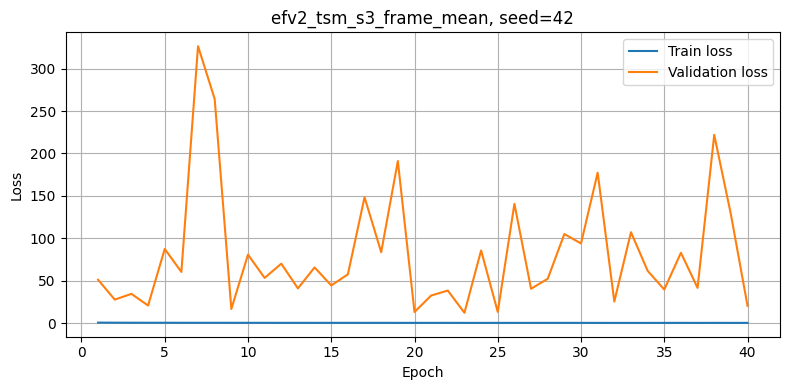

Saved: /content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/EffTempNet_EFv2TSM_S3_FrameMean_Seed42_v1/efv2_tsm_s3_frame_mean/seed_42/loss_curve.png


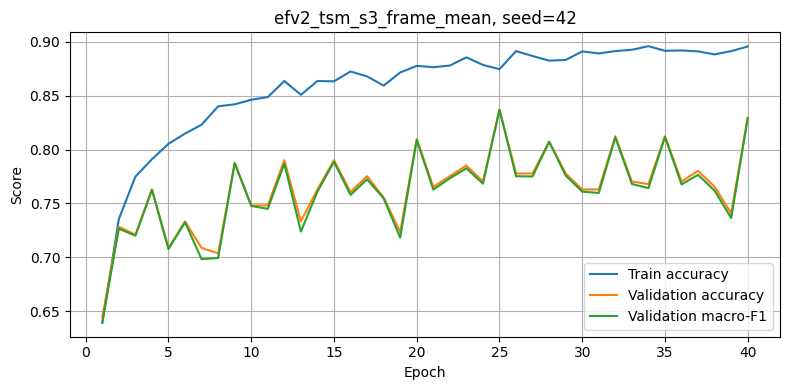

Saved: /content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/EffTempNet_EFv2TSM_S3_FrameMean_Seed42_v1/efv2_tsm_s3_frame_mean/seed_42/score_curve.png
✅ E1 selesai untuk seed: [42]


In [13]:
VARIANT_TO_RUN = "efv2_tsm_s3_frame_mean"
variants_to_run = [
    VARIANT_TO_RUN
]

all_run_metrics = []

for seed in SEEDS:
    result_df = run_experiment(
        variant=VARIANT_TO_RUN,
        seed=seed,
    )

    all_run_metrics.append(
        result_df
    )

print(
    f"✅ E1 selesai untuk seed: {SEEDS}"
)


## 8. Ringkasan hasil E1

Eksperimen awal ini hanya menggunakan seed 0. Format output tetap kompatibel dengan pipeline FrameMean sehingga seed tambahan dapat dijalankan kemudian bila E1 menunjukkan sinyal yang menjanjikan.


In [14]:

def load_all_completed_metrics() -> pd.DataFrame:
    frames = []
    variants = list(REQUIRED_VARIANTS)
    for variant in variants:
        for seed in SEEDS:
            path = OUTPUT_DIR / variant / f"seed_{seed}" / "test_metrics.csv"
            if path.exists():
                frames.append(pd.read_csv(path))
            else:
                print("Missing:", path)

    if not frames:
        raise RuntimeError("Belum ada test_metrics.csv yang selesai.")
    return pd.concat(frames, ignore_index=True)

all_metrics_df = load_all_completed_metrics()
all_metrics_df.to_csv(OUTPUT_DIR / "all_seed_metrics.csv", index=False)

aggregate_columns = [
    "accuracy",
    "balanced_accuracy",
    "f1_macro",
    "precision_violence",
    "recall_violence",
    "f1_violence",
    "roc_auc",
    "average_precision",
]

summary_df = (
    all_metrics_df
    .groupby(["variant", "dataset"])[aggregate_columns]
    .agg(["mean", "std", "min", "max"])
    .reset_index()
)
summary_df.columns = [
    "_".join([str(part) for part in col if str(part)])
    if isinstance(col, tuple) else col
    for col in summary_df.columns
]
# Pisahkan hasil in-domain (6 benchmark + pooled) dari domain held-out RWF
summary_df.to_csv(OUTPUT_DIR / "summary_mean_std.csv", index=False)

# --- definisikan dulu, sebelum dipakai di mana pun ---
display_columns = [
    "variant", "dataset",
    "accuracy_mean", "accuracy_std",
    "f1_violence_mean", "f1_violence_std",
    "roc_auc_mean", "roc_auc_std",
    "average_precision_mean", "average_precision_std",
]
available_display = [c for c in display_columns if c in summary_df.columns]

# --- hasil in-domain: 6 benchmark + ALL_TESTS_POOLED ---
indomain_df = summary_df[summary_df["dataset"] != "RWF"]
indomain_df.to_csv(OUTPUT_DIR / "summary_indomain.csv", index=False)
print("=== IN-DOMAIN (6 benchmark + pooled 411) ===")
display(indomain_df[available_display].round(4))

# --- domain held-out: RWF-2000 ---
heldout_df = summary_df[summary_df["dataset"] == "RWF"]
if not heldout_df.empty:
    heldout_df.to_csv(OUTPUT_DIR / "summary_heldout_rwf.csv", index=False)
    print("\n=== HELD-OUT DOMAIN: RWF-2000 ===")
    display(heldout_df[available_display].round(4))
else:
    print("\n[!] Baris RWF tidak ditemukan — cek TEST_SPECS dan cache RWF.")


=== IN-DOMAIN (6 benchmark + pooled 411) ===


,variant,dataset,accuracy_mean,accuracy_std,f1_violence_mean,f1_violence_std,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std
0,efv2_tsm_s3_frame_mean,ALL_TESTS_POOLED,0.8613,NaN,0.8512,NaN,0.8975,NaN,0.9368,NaN
1,efv2_tsm_s3_frame_mean,AVDV,0.8286,NaN,0.8571,NaN,0.9493,NaN,0.9759,NaN
2,efv2_tsm_s3_frame_mean,HF,0.8500,NaN,0.8235,NaN,0.7944,NaN,0.8921,NaN
3,efv2_tsm_s3_frame_mean,MF,0.9500,NaN,0.9474,NaN,0.9900,NaN,0.9909,NaN
4,efv2_tsm_s3_frame_mean,RLVS,0.8800,NaN,0.8723,NaN,0.9210,NaN,0.9488,NaN
6,efv2_tsm_s3_frame_mean,SCFD,0.7000,NaN,0.6400,NaN,0.6978,NaN,0.7756,NaN
7,efv2_tsm_s3_frame_mean,VCF,0.9231,NaN,0.9167,NaN,0.9822,NaN,0.9838,NaN



=== HELD-OUT DOMAIN: RWF-2000 ===


,variant,dataset,accuracy_mean,accuracy_std,f1_violence_mean,f1_violence_std,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std
5,efv2_tsm_s3_frame_mean,RWF,0.5721,NaN,0.4821,NaN,0.6051,NaN,0.593,NaN


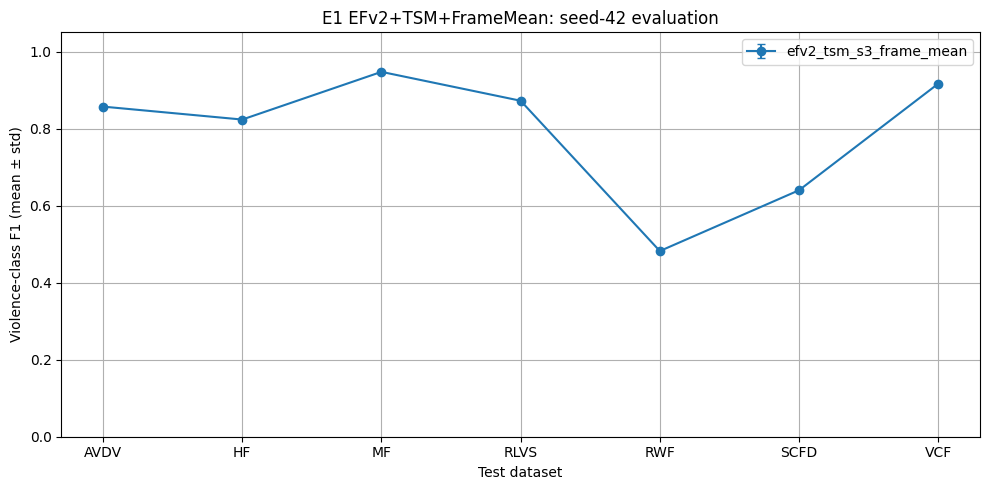

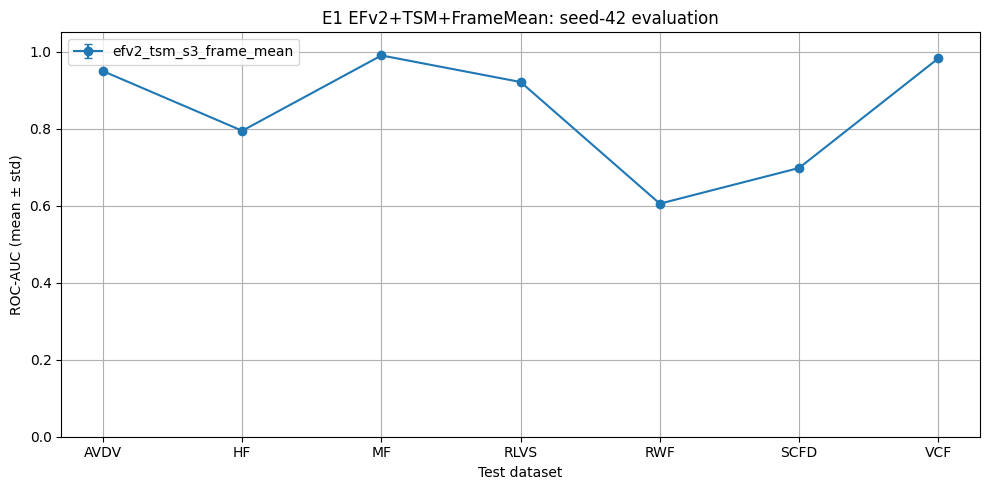

In [15]:

# Visualisasi ringkas performa.
plot_data = (
    all_metrics_df[all_metrics_df["dataset"] != "ALL_TESTS_POOLED"]
    .groupby(["variant", "dataset"], as_index=False)
    .agg(
        f1_violence_mean=("f1_violence", "mean"),
        f1_violence_std=("f1_violence", "std"),
        auc_mean=("roc_auc", "mean"),
        auc_std=("roc_auc", "std"),
    )
)

fig, ax = plt.subplots(figsize=(10, 5))
for variant, frame in plot_data.groupby("variant"):
    ax.errorbar(
        frame["dataset"],
        frame["f1_violence_mean"],
        yerr=frame["f1_violence_std"],
        marker="o",
        capsize=3,
        label=variant,
    )
ax.set_ylim(0, 1.05)
ax.set_ylabel("Violence-class F1 (mean ± std)")
ax.set_xlabel("Test dataset")
ax.set_title(
    f"E1 EFv2+TSM+FrameMean: seed-{SEEDS[0]} evaluation"
)
ax.grid(True)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "aggregate_f1_violence.png", dpi=200)
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
for variant, frame in plot_data.groupby("variant"):
    ax.errorbar(
        frame["dataset"],
        frame["auc_mean"],
        yerr=frame["auc_std"],
        marker="o",
        capsize=3,
        label=variant,
    )
ax.set_ylim(0, 1.05)
ax.set_ylabel("ROC-AUC (mean ± std)")
ax.set_xlabel("Test dataset")
ax.set_title(
    f"E1 EFv2+TSM+FrameMean: seed-{SEEDS[0]} evaluation"
)
ax.grid(True)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "aggregate_roc_auc.png", dpi=200)
plt.show()


## 9. Runtime complexity/latency diagnostic

Bagian ini adalah diagnostic benchmark pada runtime saat notebook dijalankan, bukan final CPU deployment profiling.

- input: `1 × 16 × 3 × 64 × 64`;
- TSM aktif setelah EfficientFormerV2 Stage 3;
- TSM tidak menambahkan trainable parameter;
- final aggregation tetap FrameMean;
- tidak ada BiLSTM atau temporal attention;
- `ptflops` terutama merepresentasikan arithmetic MACs dan tidak merepresentasikan seluruh biaya memory movement dari temporal shift.


In [16]:

def synchronize_device():
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()


@torch.inference_mode()
def benchmark_model_latency(
    model: nn.Module,
    warmup: int = LATENCY_WARMUP,
    runs: int = LATENCY_RUNS,
) -> Dict[str, float]:
    model.eval()

    dummy = torch.randn(
        1,
        SEQUENCE_LENGTH,
        3,
        RAW_HEIGHT,
        RAW_WIDTH,
        device=DEVICE,
    )

    # Warm-up.
    for _ in range(warmup):
        _ = model(dummy)

    synchronize_device()

    times_ms = []

    for _ in range(runs):
        synchronize_device()
        start = time.perf_counter()

        _ = model(dummy)

        synchronize_device()
        elapsed_ms = (time.perf_counter() - start) * 1000.0
        times_ms.append(elapsed_ms)

    times_ms = np.asarray(times_ms, dtype=np.float64)

    return {
        "latency_mean_ms": float(times_ms.mean()),
        "latency_std_ms": float(times_ms.std(ddof=0)),
        "latency_p50_ms": float(np.percentile(times_ms, 50)),
        "latency_p90_ms": float(np.percentile(times_ms, 90)),
        "latency_p95_ms": float(np.percentile(times_ms, 95)),
        "latency_p99_ms": float(np.percentile(times_ms, 99)),
    }


def benchmark_completed_model(
    variant: str,
    seed: int,
) -> Dict[str, object]:
    checkpoint_path = (
        OUTPUT_DIR
        / variant
        / f"seed_{seed}"
        / "best.pt"
    )

    if not checkpoint_path.exists():
        raise FileNotFoundError(checkpoint_path)

    set_global_seed(seed)

    model = EfficientFormerTSMFrameMean(
        variant=variant,
        pretrained=False,
    ).to(DEVICE)

    checkpoint = safe_torch_load(
        checkpoint_path,
        map_location=DEVICE,
    )

    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    total_params, trainable_params = count_parameters(model)

    result = {
        "variant": variant,
        "seed_checkpoint": seed,
        "device": str(DEVICE),
        "device_name": (
            torch.cuda.get_device_name(0)
            if DEVICE.type == "cuda"
            else platform.processor()
        ),
        "total_parameters": total_params,
        "trainable_parameters": trainable_params,
        "input_shape": [1, SEQUENCE_LENGTH, 3, RAW_HEIGHT, RAW_WIDTH],
        "backbone_internal_resolution": [
            BACKBONE_INPUT_SIZE,
            BACKBONE_INPUT_SIZE,
        ],
        "uses_tsm": True,
        "tsm_shift_div": TSM_SHIFT_DIV,
        "tsm_after_stage_indices": list(TSM_AFTER_STAGE_INDICES),
        "tsm_placement_name": TSM_PLACEMENT_NAME,
        "uses_bilstm": False,
        "uses_temporal_attention": False,
        "temporal_aggregation": "mean_of_tsm_mixed_frame_features",
        "label_smoothing": 0.0,
    }

    result.update(benchmark_model_latency(model))

    try:
        from ptflops import get_model_complexity_info

        macs, params = get_model_complexity_info(
            model,
            (SEQUENCE_LENGTH, 3, RAW_HEIGHT, RAW_WIDTH),
            as_strings=False,
            print_per_layer_stat=False,
            verbose=False,
        )

        result["ptflops_macs"] = float(macs)
        result["ptflops_gmacs"] = float(macs / 1e9)
        result["ptflops_parameters"] = float(params)

    except Exception as error:
        result["ptflops_error"] = repr(error)

    del model

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result


# Audit checkpoint yang akan dipakai.
VARIANT_TO_RUN = "efv2_tsm_s3_frame_mean"
variants_to_run = [VARIANT_TO_RUN]
BENCHMARK_SEED = SEEDS[0]

run_dir = (
    OUTPUT_DIR
    / VARIANT_TO_RUN
    / f"seed_{BENCHMARK_SEED}"
)

files_to_check = {
    "best checkpoint": run_dir / "best.pt",
    "last checkpoint": run_dir / "last.pt",
    "training history": run_dir / "history.csv",
    "test metrics": run_dir / "test_metrics.csv",
    "completion marker": run_dir / "completed.json",
}

print("Run directory:", run_dir)
print()

for name, path in files_to_check.items():
    print(f"{name:20s}: {path.exists()} | {path}")


Run directory: /content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/EffTempNet_EFv2TSM_S3_FrameMean_Seed42_v1/efv2_tsm_s3_frame_mean/seed_42

best checkpoint     : True | /content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/EffTempNet_EFv2TSM_S3_FrameMean_Seed42_v1/efv2_tsm_s3_frame_mean/seed_42/best.pt
last checkpoint     : True | /content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/EffTempNet_EFv2TSM_S3_FrameMean_Seed42_v1/efv2_tsm_s3_frame_mean/seed_42/last.pt
training history    : True | /content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/EffTempNet_EFv2TSM_S3_FrameMean_Seed42_v1/efv2_tsm_s3_frame_mean/seed_42/history.csv
test metrics        : True | /content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/EffTempNet_EFv2TSM_S3_FrameMean_Seed42_v1/efv2_tsm_s3_frame_mean/seed_42/test_metrics.csv
completion marker   : True | /content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/EffTempNet_EFv2TSM_S3_FrameMean_Seed42_v1/efv2_tsm_

In [17]:
VARIANT_TO_RUN = "efv2_tsm_s3_frame_mean"
variants_to_run = [VARIANT_TO_RUN]
BENCHMARK_SEED = SEEDS[0]

benchmark_rows = []

for variant in variants_to_run:
    checkpoint_path = (
        OUTPUT_DIR
        / variant
        / f"seed_{BENCHMARK_SEED}"
        / "best.pt"
    )

    print("Checkpoint yang dicari:", checkpoint_path)
    print("Checkpoint tersedia:", checkpoint_path.exists())

    if not checkpoint_path.exists():
        print(
            f"⚠️ Benchmark dilewati karena best.pt seed "
            f"{BENCHMARK_SEED} tidak ditemukan."
        )
        continue

    benchmark_rows.append(
        benchmark_completed_model(
            variant=variant,
            seed=BENCHMARK_SEED,
        )
    )

if benchmark_rows:
    benchmark_df = pd.DataFrame(benchmark_rows)

    benchmark_output = (
        OUTPUT_DIR
        / f"efficiency_benchmark_{VARIANT_TO_RUN}"
          f"_seed_{BENCHMARK_SEED}.csv"
    )

    benchmark_df.to_csv(
        benchmark_output,
        index=False,
    )

    display(benchmark_df.T)
    print("Saved:", benchmark_output)
else:
    print("Tidak ada checkpoint yang berhasil dibenchmark.")


Checkpoint yang dicari: /content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/EffTempNet_EFv2TSM_S3_FrameMean_Seed42_v1/efv2_tsm_s3_frame_mean/seed_42/best.pt
Checkpoint tersedia: True


,0
variant,efv2_tsm_s3_frame_mean
seed_checkpoint,42
device,cuda
device_name,NVIDIA A100-SXM4-40GB
total_parameters,3334866
trainable_parameters,3334866
input_shape,"[1, 16, 3, 64, 64]"
backbone_internal_resolution,"[224, 224]"
uses_tsm,True
tsm_shift_div,8


Saved: /content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/EffTempNet_EFv2TSM_S3_FrameMean_Seed42_v1/efficiency_benchmark_efv2_tsm_s3_frame_mean_seed_42.csv


## 10. Optional paired comparison against FrameMean seed 0

Jika baseline FrameMean seed 0 sudah tersedia, cell berikut menghitung selisih AP, ROC-AUC, dan Macro-F1 antara E1 dan FrameMean pada dataset yang sama.

RWF hanya digunakan sebagai held-out evaluation; jangan menggunakan hasil ini untuk memilih placement TSM alternatif.


In [18]:
COMPARISON_SEED = RUN_SEED
BASELINE_FRAMEMEAN_DIR = Path(
    "/content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/"
    "EffTempNet_FrameMean_NoLS_0Seeds_v1"
)

baseline_metrics_path = (
    BASELINE_FRAMEMEAN_DIR
    / "frame_mean"
    / f"seed_{COMPARISON_SEED}"
    / "test_metrics.csv"
)

e1_metrics_path = (
    OUTPUT_DIR
    / VARIANT_TO_RUN
    / f"seed_{COMPARISON_SEED}"
    / "test_metrics.csv"
)

if (
    baseline_metrics_path.exists()
    and e1_metrics_path.exists()
):
    baseline_df = pd.read_csv(
        baseline_metrics_path
    )
    e1_df = pd.read_csv(
        e1_metrics_path
    )

    keep = [
        "dataset",
        "average_precision",
        "roc_auc",
        "f1_macro",
    ]

    baseline_cmp = (
        baseline_df[keep]
        .rename(
            columns={
                "average_precision":
                    "baseline_ap",
                "roc_auc":
                    "baseline_auc",
                "f1_macro":
                    "baseline_f1_macro",
            }
        )
    )

    e1_cmp = (
        e1_df[keep]
        .rename(
            columns={
                "average_precision":
                    "e1_ap",
                "roc_auc":
                    "e1_auc",
                "f1_macro":
                    "e1_f1_macro",
            }
        )
    )

    comparison_df = baseline_cmp.merge(
        e1_cmp,
        on="dataset",
        how="inner",
        validate="one_to_one",
    )

    comparison_df[
        "delta_ap_pp"
    ] = (
        comparison_df["e1_ap"]
        - comparison_df["baseline_ap"]
    ) * 100.0

    comparison_df[
        "delta_auc_pp"
    ] = (
        comparison_df["e1_auc"]
        - comparison_df["baseline_auc"]
    ) * 100.0

    comparison_df[
        "delta_f1_macro_pp"
    ] = (
        comparison_df["e1_f1_macro"]
        - comparison_df["baseline_f1_macro"]
    ) * 100.0

    display(
        comparison_df.round(4)
    )

    comparison_output = (
        OUTPUT_DIR
        / f"E1_vs_FrameMean_seed{COMPARISON_SEED}.csv"
    )

    comparison_df.to_csv(
        comparison_output,
        index=False,
    )

    print(
        "Saved:",
        comparison_output,
    )

else:
    print(
        "Baseline or E1 test_metrics.csv "
        "is not available yet."
    )
    print(
        "Baseline expected:",
        baseline_metrics_path,
    )
    print(
        "E1 expected:",
        e1_metrics_path,
    )


Baseline or E1 test_metrics.csv is not available yet.
Baseline expected: /content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/EffTempNet_FrameMean_NoLS_0Seeds_v1/frame_mean/seed_42/test_metrics.csv
E1 expected: /content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/EffTempNet_EFv2TSM_S3_FrameMean_Seed42_v1/efv2_tsm_s3_frame_mean/seed_42/test_metrics.csv


## 11. Paket hasil

Folder output berisi:
- best dan last checkpoint untuk setiap seed;
- konfigurasi dan `history.csv` setiap run;
- `loss_curve.png` dan `score_curve.png` setiap seed;
- prediksi per test dataset;
- confusion matrix dan ROC curve;
- bootstrap confidence interval;
- tabel seluruh seed dan mean ± standard deviation;
- benchmark perangkat runtime saat ini;
- arsip ZIP seluruh hasil.


In [19]:

archive_base = str(OUTPUT_DIR.parent / f"{OUTPUT_DIR.name}_results")
archive_path = shutil.make_archive(archive_base, "zip", root_dir=OUTPUT_DIR)
print("Archive created:", archive_path)
print("Semua hasil juga tetap tersimpan di:", OUTPUT_DIR)


Archive created: /content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/EffTempNet_EFv2TSM_S3_FrameMean_Seed42_v1_results.zip
Semua hasil juga tetap tersimpan di: /content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/EffTempNet_EFv2TSM_S3_FrameMean_Seed42_v1
